In [98]:
""" Task 3: Comparing temperature data from 100 years ago """

' Task 3: Comparing temperature data from 100 years ago '

In [99]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt

In [100]:
""" Personal id and website to request data from """
client_id = open('C:/Users/danie/Documents/NMBU 4.år/Inf 201/W41_42/Client_id_frostmet.txt').read().strip()
endpoint = 'https://frost.met.no/observations/v0.jsonld'

In [101]:
""" Parameters to source data """

params_2025 = {
    'sources': 'SN17850',
    'elements': 'mean(air_temperature P1D)',
    'referencetime': '2025-01-01/2026-01-01'
}

params_1925 ={
    'sources': 'SN17850',
    'elements': 'mean(air_temperature P1D)',
    'referencetime': '1925-01-01/1926-01-01'
}

In [102]:
""" Requesting data """

response_2025 = requests.get(endpoint, params_2025, auth=(client_id, ""))
response_1925 = requests.get(endpoint, params_1925, auth=(client_id, ""))
print(response_2025.status_code,',', response_1925.status_code)         #status_code == 200 --> OK!, 400 and 401 --> bad:(

200 , 200


In [103]:
""" Turning json file from website into python objects i.e. dict"""

payload_2025 = response_2025.json()
payload_1925 = response_1925.json()

print(type(payload_1925), type(payload_2025))


<class 'dict'> <class 'dict'>


In [104]:
data_2025 = [{'Time': pd.to_datetime(entry['referenceTime']), 
              'Average daily temperature 2025 [C]': entry['observations'][0]['value']}
              for entry in payload_2025['data']]

data_1925 = [{'Time': pd.to_datetime(entry['referenceTime']), 
              'Average daily temperature 1925 [C]': entry['observations'][0]['value']}
              for entry in payload_1925['data']]
data_1925[0:10]

[{'Time': Timestamp('1925-01-01 00:00:00+0000', tz='UTC'),
  'Average daily temperature 1925 [C]': 1.3},
 {'Time': Timestamp('1925-01-02 00:00:00+0000', tz='UTC'),
  'Average daily temperature 1925 [C]': 4.1},
 {'Time': Timestamp('1925-01-03 00:00:00+0000', tz='UTC'),
  'Average daily temperature 1925 [C]': 2.1},
 {'Time': Timestamp('1925-01-04 00:00:00+0000', tz='UTC'),
  'Average daily temperature 1925 [C]': 0.1},
 {'Time': Timestamp('1925-01-05 00:00:00+0000', tz='UTC'),
  'Average daily temperature 1925 [C]': -2.2},
 {'Time': Timestamp('1925-01-06 00:00:00+0000', tz='UTC'),
  'Average daily temperature 1925 [C]': -1.2},
 {'Time': Timestamp('1925-01-07 00:00:00+0000', tz='UTC'),
  'Average daily temperature 1925 [C]': 3.8},
 {'Time': Timestamp('1925-01-08 00:00:00+0000', tz='UTC'),
  'Average daily temperature 1925 [C]': 3.1},
 {'Time': Timestamp('1925-01-09 00:00:00+0000', tz='UTC'),
  'Average daily temperature 1925 [C]': 2.5},
 {'Time': Timestamp('1925-01-10 00:00:00+0000', tz='U

In [105]:
df_2025 = pd.DataFrame(data_2025)
df_1925 = pd.DataFrame(data_1925)
df_2025['doy'] = df_2025['Time'].dt.dayofyear
df_1925['doy'] = df_1925['Time'].dt.dayofyear 

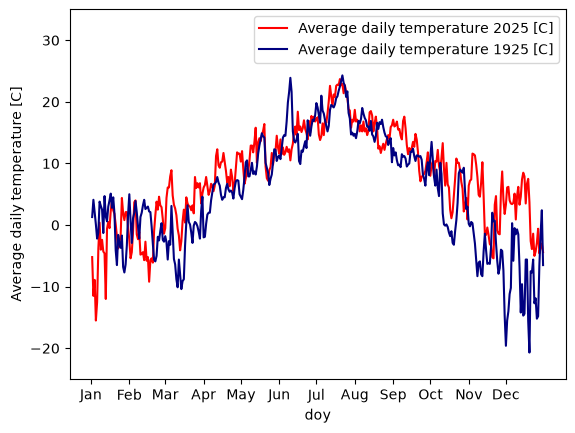

In [106]:
""" Create the comparison plots """

y_2025 = 'Average daily temperature 2025 [C]'
y_1925 = 'Average daily temperature 1925 [C]'

fig, ax1 = plt.subplots()

df_2025.plot(x = 'doy', y= y_2025 , kind='line',
             color='red', label = y_2025, ax = ax1)
ax1.set_ylim(-25, 35)
ax1.set_ylabel('Average daily temperature [C]')
#mark every start of month as a tick along x-axis
ax1.set_xticks([0, 31, 60, 91, 121, 152, 182, 213,
                244, 274, 305, 335])
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr',
                     'May', 'Jun' ,'Jul', 'Aug',
                     'Sep', 'Oct', 'Nov', 'Dec'])


ax2 = ax1
df_1925.plot(x='doy', y=y_1925, kind='line',
             color='navy', label= y_1925, ax = ax2)

plt.show()


In [107]:
"""Summary stats for 1925 and 2025 """
min_temp_1925 = df_1925['Average daily temperature 1925 [C]'].min()
max_temp_1925 = df_1925['Average daily temperature 1925 [C]'].max()
mean_temp_1925 = df_1925['Average daily temperature 1925 [C]'].mean()
median_temp_1925 = df_1925['Average daily temperature 1925 [C]'].median()

min_temp_2025 = df_2025['Average daily temperature 2025 [C]'].min()
max_temp_2025 = df_2025['Average daily temperature 2025 [C]'].max()
mean_temp_2025 = df_2025['Average daily temperature 2025 [C]'].mean()
median_temp_2025 = df_2025['Average daily temperature 2025 [C]'].median()

""" Summary table """
spacer = 13
print(f"""
{('~')*spacer} Temperature comparison 1925 <--> 2025 {('~')*spacer}

Mininum daily average temperature:  {min_temp_1925} <--> {min_temp_2025}
Maximum daily average temperature:   {max_temp_1925} <-->  {max_temp_2025}
Average yearly temperature:           {mean_temp_1925:.1f} <-->   {mean_temp_2025:.1f}
Median temperature:                   {median_temp_1925} <-->   {median_temp_2025}""")


~~~~~~~~~~~~~ Temperature comparison 1925 <--> 2025 ~~~~~~~~~~~~~

Mininum daily average temperature:  -20.7 <--> -15.5
Maximum daily average temperature:   24.3 <-->  23.7
Average yearly temperature:           5.3 <-->   7.9
Median temperature:                   5.3 <-->   8.3
